# Create File Train/Val/Test Split

In [4]:
import pandas as pd 
import numpy as np 
import os 
import ast
import librosa 
import matplotlib.pyplot as plt
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
from src.args.yaml_config import YamlConfig

yaml_config = YamlConfig().config

In [ ]:
#change current data directory to the root of the project
os.chdir("/root/birdclef/")

In [ ]:
taxonomy_df = pd.read_csv(yaml_config.base_data_dir + "/taxonomy.csv")
sample_submission_df = pd.read_csv(yaml_config.base_data_dir + "/sample_submission.csv")
train_soundscapes_labels_df = pd.read_csv(yaml_config.base_data_dir + "/train_soundscapes_labels.csv")
train_df = pd.read_csv(yaml_config.base_data_dir + "/train.csv")
train_df["unique_file_id"] = train_df["filename"].apply(lambda x: x.split("/")[-1])

train_audio_path = yaml_config.base_data_dir + "/train_audio/"
train_soundscapes_path = yaml_config.base_data_dir + "/train_soundscapes/"

,primary_label,secondary_labels,type,latitude,longitude,scientific_name,common_name,class_name,inat_taxon_id,author,license,rating,url,filename,collection,unique_file_id
0,1161364,[],[],-22.7562,-46.8666,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1216197....,1161364/iNat1216197.ogg,iNat,iNat1216197.ogg
1,1161364,[],[],-22.7558,-46.8700,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1114648....,1161364/iNat1114648.ogg,iNat,iNat1114648.ogg
2,1161364,[],[],-22.7547,-46.8728,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/810195.m...,1161364/iNat810195.ogg,iNat,iNat810195.ogg
3,1161364,[],[],-22.7547,-46.8728,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/818781.m...,1161364/iNat818781.ogg,iNat,iNat818781.ogg
4,1161364,[],[],-22.7426,-46.8985,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/556514.m...,1161364/iNat556514.ogg,iNat,iNat556514.ogg


In [7]:
def get_file_names(audio_folder_path):
    file_names = []
    
    #recursively walk through the audio folder and its subfolders 
    for root, dirs, files in os.walk(audio_folder_path):
        for file in files:
            if file.endswith(".ogg"):
                complete_file_path = os.path.join(root, file)
                file_names.append(complete_file_path)
    return file_names

In [8]:
def get_train_audio_labels(file_path):
    #get the label for the given filename from the train_df
    #get file
    filename = os.path.basename(file_path)
    label = train_df[train_df["unique_file_id"] == filename]["primary_label"].values[0]
    secondary_labels = train_df[train_df["unique_file_id"] == filename]["secondary_labels"].values[0]
    labels = [label]
    
    if pd.notna(secondary_labels):
        #get as list 
        secondary_labels = ast.literal_eval(secondary_labels)
        labels.extend(secondary_labels)  # Add secondary labels to the list of labels
    labels = list(set(labels))  # Remove duplicates if any
    return labels 

def get_train_soundscapes_labels(file_path):
    #get the label for the given filename from the train_soundscapes_labels_df
    filename = os.path.basename(file_path)
    labels = []
    print(filename)
    primary_labels_windows = train_soundscapes_labels_df[train_soundscapes_labels_df["filename"] == filename]["primary_label"]
    print("primary_labels_windows:", primary_labels_windows)
    for primary_labels_window in primary_labels_windows:
        window_labels = primary_labels_window.split(";")
        print("window_labels:", window_labels)
        labels.extend(window_labels)
    labels = list(set(labels))  # Remove duplicates if any
    return labels

In [ ]:
#filename; label 
train_audio_files = get_file_names(train_audio_path)
train_soundscapes_files = get_file_names(train_soundscapes_path)

train_audio_dict = {filename: get_train_audio_labels(filename) for filename in train_audio_files}
train_soundscapes_dict = {filename: get_train_soundscapes_labels(filename) for filename in train_soundscapes_files}

#fuse the two dictionaries
fused_dict = {**train_audio_dict, **train_soundscapes_dict}

#df 
fused_df = pd.DataFrame(list(fused_dict.items()), columns=["filename", "labels"])
#filter out rows with empty labels
fused_df = fused_df[fused_df["labels"].map(len) > 0]

BC2026_Train_5850_S13_20221109_004500.ogg
primary_labels_windows: Series([], Name: primary_label, dtype: object)
BC2026_Train_1952_S01_20231201_223000.ogg
primary_labels_windows: Series([], Name: primary_label, dtype: object)
BC2026_Train_4876_S02_20240226_231500.ogg
primary_labels_windows: Series([], Name: primary_label, dtype: object)
BC2026_Train_8457_S22_20221112_014500.ogg
primary_labels_windows: Series([], Name: primary_label, dtype: object)
BC2026_Train_10380_S22_20240413_034500.ogg
primary_labels_windows: Series([], Name: primary_label, dtype: object)
BC2026_Train_1249_S01_20230307_204500.ogg
primary_labels_windows: Series([], Name: primary_label, dtype: object)
BC2026_Train_3680_S02_20221019_201500.ogg
primary_labels_windows: Series([], Name: primary_label, dtype: object)
BC2026_Train_0154_S07_20140111_220000.ogg
primary_labels_windows: Series([], Name: primary_label, dtype: object)
BC2026_Train_1387_S01_20230405_180000.ogg
primary_labels_windows: Series([], Name: primary_labe

In [10]:
fused_df.to_csv("fused_labels.csv", index=False)

In [11]:
# perform multilabel split to have every unique label in the train and validation set
train_size = 0.7 
val_size = 0.15
test_size = 0.15

In [12]:
#class mapping 
class_mapping = {label: idx for idx, label in enumerate(sorted(taxonomy_df['primary_label'].unique()))}

In [13]:
print("class_mapping:", class_mapping)

class_mapping: {'1161364': 0, '116570': 1, '1176823': 2, '1491113': 3, '1595929': 4, '209233': 5, '22930': 6, '22956': 7, '22961': 8, '22967': 9, '22973': 10, '22983': 11, '22985': 12, '23150': 13, '23154': 14, '23158': 15, '23176': 16, '23724': 17, '24279': 18, '24285': 19, '24287': 20, '24321': 21, '244024': 22, '25073': 23, '25092': 24, '25214': 25, '326272': 26, '41970': 27, '43435': 28, '47144': 29, '47158son01': 30, '47158son02': 31, '47158son03': 32, '47158son04': 33, '47158son05': 34, '47158son06': 35, '47158son07': 36, '47158son08': 37, '47158son09': 38, '47158son10': 39, '47158son11': 40, '47158son12': 41, '47158son13': 42, '47158son14': 43, '47158son15': 44, '47158son16': 45, '47158son17': 46, '47158son18': 47, '47158son19': 48, '47158son20': 49, '47158son21': 50, '47158son22': 51, '47158son23': 52, '47158son24': 53, '47158son25': 54, '476521': 55, '516975': 56, '517063': 57, '555123': 58, '555145': 59, '555146': 60, '64898': 61, '65377': 62, '65380': 63, '66971': 64, '67107

In [14]:

random_state = 42
np.random.seed(random_state)

# Let's target a 70% Train, 15% Val, 15% Test split.
X = np.array([i for i in range(len(fused_df))])  # Just an index array for splitting
y = np.array([[0] * len(class_mapping) for _ in range(len(fused_df))])  # one hot vectors of labels for each sample
for idx, labels in enumerate(fused_df["labels"]):
    for label in labels:
        label_idx = class_mapping[label]
        y[idx][label_idx] = 1 

# ---------------------------------------------------------
# Step 1: Split into Temp (70%) and Test (30%)
msss1 = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)

for temp_index, test_index in msss1.split(X, y):
    X_temp, X_test = X[temp_index], X[test_index]
    y_temp, y_test = y[temp_index], y[test_index]

# ---------------------------------------------------------
# Step 2: Split Temp into Train (70%) and Val (30%)
#recalculate percentages for train and val based on the new temp size
val_size = val_size / (train_size + val_size)  # Adjust val_size to
msss2 = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=val_size, random_state=random_state)

for train_index, val_index in msss2.split(X_temp, y_temp):
    X_train, X_val = X_temp[train_index], X_temp[val_index]
    y_train, y_val = y_temp[train_index], y_temp[val_index]

# ---------------------------------------------------------
# Verification
# ---------------------------------------------------------
print(f"Total samples: {len(X)}")
print(f"Train samples: {len(X_train)}")
print(f"Val samples:   {len(X_val)}")
print(f"Test samples:  {len(X_test)}\n")

print("Label distributions (sum of positive classes):")
print(f"Original: {y.sum(axis=0)}")
print(f"Train:    {y_train.sum(axis=0)}")
print(f"Val:      {y_val.sum(axis=0)}")
print(f"Test:     {y_test.sum(axis=0)}")

Total samples: 35615
Train samples: 25084
Val samples:   5299
Test samples:  5232

Label distributions (sum of positive classes):
Original: [  11    9   12    8    5    2    6   32    9   22   84   10    6    1
    5   43    4    1   69   19   12   21  181    1   32    3   33   21
   16   48    2    1    3    3    2    2    4    2    1    4    3    1
    3    1    1    1    4    1    2    1    2    2    2    2    7    3
    6   40    3    9   40    3   47   53   23   18    7    2    5   11
    3    7  140  142   54  342  616  550  304  230  505   66  216  113
   59  169   73  571  576  148  474  222  134  246  212  239  137  173
  284  394  145   42  513  565  392  334   84   23  217  387  120  600
   68  285   92  275  139  121  137  513  144  567  246 1106   75  224
  477  276   98  449  117  565   72  160  131   30  423  377  109  130
  115   78   77  315   20   15  455   89  247  495  326   86  303  154
  334  428  192   38  205   95  100  286  106  201  142  233  194  251
  106  5

In [15]:
#create csvs based on x_train, x_val, x_test
train_df = fused_df.iloc[X_train]
val_df = fused_df.iloc[X_val]
test_df = fused_df.iloc[X_test]

train_df.to_csv("train_split.csv", index=False)
val_df.to_csv("val_split.csv", index=False)
test_df.to_csv("test_split.csv", index=False)

In [16]:
print(train_df.shape[0], "samples in train set")
print(val_df.shape[0], "samples in validation set")
print(test_df.shape[0], "samples in test set")

print(train_df.head(5))
print(val_df.head(5))
print(test_df.head(5))

25084 samples in train set
5299 samples in validation set
5232 samples in test set
                                            filename              labels
0  /sc/scratch/leon.hermann/kaggle/competitions/b...           [rumfly1]
1  /sc/scratch/leon.hermann/kaggle/competitions/b...  [undtin1, rumfly1]
3  /sc/scratch/leon.hermann/kaggle/competitions/b...           [rumfly1]
4  /sc/scratch/leon.hermann/kaggle/competitions/b...           [rumfly1]
5  /sc/scratch/leon.hermann/kaggle/competitions/b...           [rumfly1]
                                             filename  \
2   /sc/scratch/leon.hermann/kaggle/competitions/b...   
12  /sc/scratch/leon.hermann/kaggle/competitions/b...   
14  /sc/scratch/leon.hermann/kaggle/competitions/b...   
26  /sc/scratch/leon.hermann/kaggle/competitions/b...   
27  /sc/scratch/leon.hermann/kaggle/competitions/b...   

                                 labels  
2                             [rumfly1]  
12                            [rumfly1]  
14        

In [17]:
def get_label_distribution_count(df):
    #get label distribution 
    df_labels_count = {}
    for row in df.itertuples():
        labels = row.labels

        for label in labels:
            if label in df_labels_count:
                df_labels_count[label] += 1
            else:
                df_labels_count[label] = 1
    return df_labels_count

def plot_label_distribution_count(df_labels_count):
    print("Number of animals labeled in train soundscapes labels: {}".format(len(df_labels_count)))
    #print("Label distribution in train soundscapes labels:")
    #for label, count in df_labels_count.items():
    #    print(f"{label}: {count}")
    #plot label distribution in train soundscapes labels
    plt.figure(figsize=(10,5))
    plt.bar(df_labels_count.keys(), df_labels_count.values())
    plt.xlabel("Label")
    plt.ylabel("Count")
    plt.title("Label Distribution in Labels")
    plt.xticks(rotation=45)


Train Set:
Number of animals labeled in train soundscapes labels: 232

Validation Set:
Number of animals labeled in train soundscapes labels: 217

Test Set:
Number of animals labeled in train soundscapes labels: 202


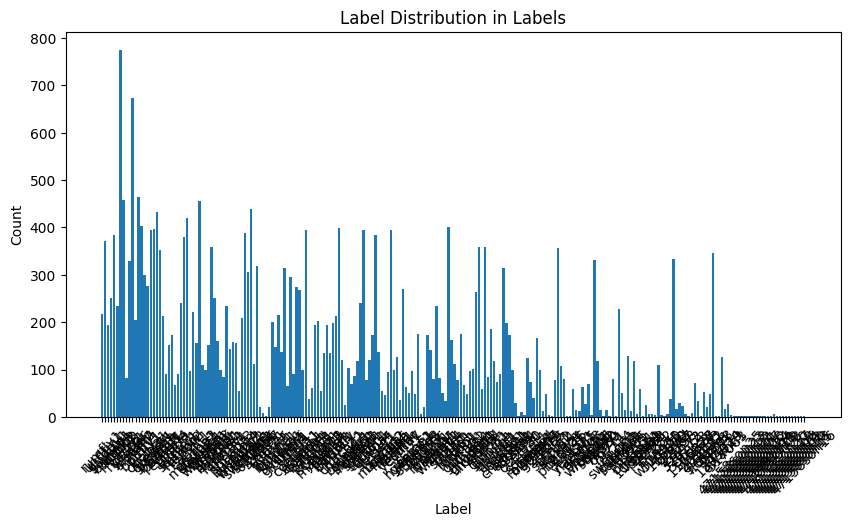

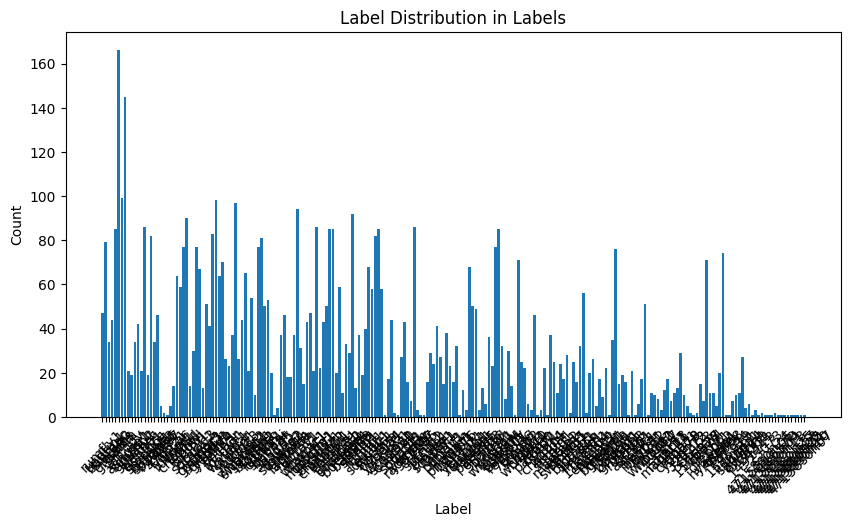

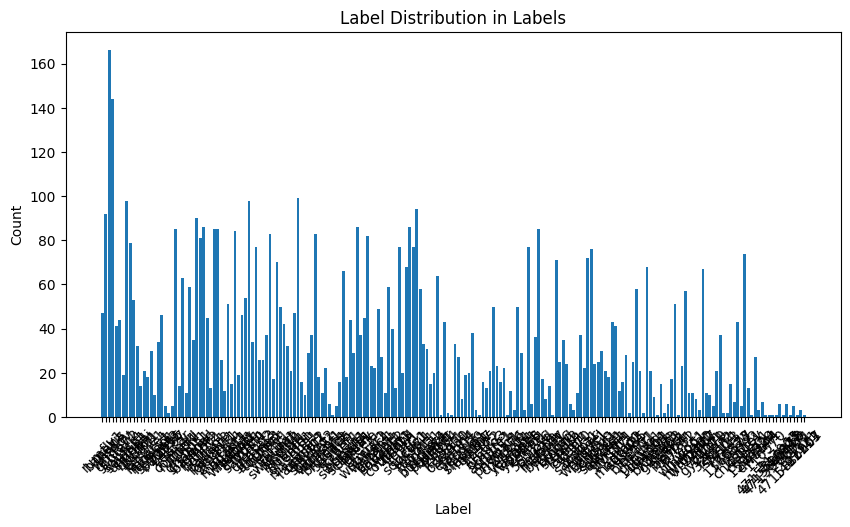

In [18]:
for df, name in zip([train_df, val_df, test_df], ["Train", "Validation", "Test"]):
    print(f"\n{name} Set:")
    df_labels_count = get_label_distribution_count(df)
    plot_label_distribution_count(df_labels_count)